# Tahap 5: Model Evaluation
**CBR - Pidana Umum: Pemalsuan**

Tujuan: Ukur dan analisis performa retrieval & prediksi sistem CBR.

**Metrik:**
- **Retrieval**: Precision@K, Recall@K, F1@K, MRR (Mean Reciprocal Rank)
- **Prediksi**: Accuracy, Precision, Recall, F1-score (per kelas vonis)
- **Analisis Kegagalan**: Error analysis dan rekomendasi perbaikan

## 1. Import & Load Data

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from pathlib import Path
from collections import Counter
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

# Path
PROCESSED_DIR = Path("../data/processed")
EVAL_DIR      = Path("../data/eval")
RESULTS_DIR   = Path("../data/results")

# Load semua artefak
with open(PROCESSED_DIR / "cases.json", encoding="utf-8") as f:
    cases = json.load(f)
case_lookup = {c["case_id"]: c for c in cases}

with open(PROCESSED_DIR / "solutions.json", encoding="utf-8") as f:
    case_solutions = json.load(f)

train_embeddings = np.load(EVAL_DIR / "train_embeddings.npy")
with open(EVAL_DIR / "train_case_ids.json") as f:
    train_case_ids = json.load(f)

with open(EVAL_DIR / "queries.json", encoding="utf-8") as f:
    test_queries = json.load(f)

with open(EVAL_DIR / "data_split.json") as f:
    split_info = json.load(f)

df_all  = pd.DataFrame(cases)
df_test = df_all[df_all["case_id"].isin(split_info["test_ids"])].reset_index(drop=True)

# Load hasil prediksi
df_pred = pd.read_csv(RESULTS_DIR / "predictions.csv")

print(f"✅ Data dimuat:")
print(f"   Total kasus : {len(cases)}")
print(f"   Test kasus  : {len(df_test)}")
print(f"   Test queries: {len(test_queries)}")
print(f"   Prediksi    : {len(df_pred)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")

✅ Data dimuat:
   Total kasus : 35
   Test kasus  : 7
   Test queries: 7
   Prediksi    : 7
🖥️  Device: cpu


## 2. Load Model untuk Re-embed Query

In [2]:
MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

def embed_text(text: str) -> np.ndarray:
    encoded = tokenizer(text, max_length=512, padding=True, truncation=True, return_tensors="pt")
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        out = model(**encoded)
    mask = encoded["attention_mask"].unsqueeze(-1).expand(out[0].size()).float()
    emb  = torch.sum(out[0] * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)
    emb  = torch.nn.functional.normalize(emb, p=2, dim=1)
    return emb.cpu().numpy()

def retrieve(query: str, k: int = 5):
    q_emb = embed_text(query.lower().strip())
    sims  = cosine_similarity(q_emb, train_embeddings)[0]
    top_k = np.argsort(sims)[::-1][:k]
    return [(train_case_ids[i], float(sims[i])) for i in top_k]

print("✅ Model siap")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model siap


## 3. Evaluasi Retrieval

In [3]:
def eval_retrieval(queries: list, ground_truth: dict, k: int = 5) -> dict:
    """
    Evaluasi performa retrieval.
    
    Args:
        queries     : List query dict (dari queries.json)
        ground_truth: {query_id: [relevant_case_ids]}
        k           : Jumlah top-k
    """
    precisions, recalls, f1s, reciprocal_ranks = [], [], [], []
    
    for q in queries:
        query_id   = q["query_id"]
        query_text = q["query_text"]
        relevant   = set(ground_truth.get(query_id, []))
        
        if not relevant:
            continue  # Skip jika tidak ada ground truth
        
        # Retrieve
        retrieved = retrieve(query_text, k=k)
        retrieved_ids = [r[0] for r in retrieved]
        
        # Hitung metrik
        retrieved_set = set(retrieved_ids)
        true_positives = len(relevant & retrieved_set)
        
        precision_k = true_positives / k
        recall_k    = true_positives / len(relevant) if relevant else 0
        f1_k        = (2 * precision_k * recall_k) / (precision_k + recall_k) \
                      if (precision_k + recall_k) > 0 else 0
        
        # Mean Reciprocal Rank
        rr = 0.0
        for rank, cid in enumerate(retrieved_ids, 1):
            if cid in relevant:
                rr = 1.0 / rank
                break
        
        precisions.append(precision_k)
        recalls.append(recall_k)
        f1s.append(f1_k)
        reciprocal_ranks.append(rr)
    
    return {
        "precision@k" : np.mean(precisions) if precisions else 0,
        "recall@k"    : np.mean(recalls) if recalls else 0,
        "f1@k"        : np.mean(f1s) if f1s else 0,
        "mrr"         : np.mean(reciprocal_ranks) if reciprocal_ranks else 0,
        "k"           : k,
        "n_queries"   : len(precisions)
    }


# Siapkan ground truth dari queries.json
ground_truth = {
    q["query_id"]: q["ground_truth_case_ids"]
    for q in test_queries
}

# Filter queries yang memiliki ground truth
valid_queries = [q for q in test_queries if ground_truth.get(q["query_id"])]
print(f"📊 Query dengan ground truth: {len(valid_queries)} dari {len(test_queries)}")

# Evaluasi di berbagai nilai K
retrieval_results = {}
for k_val in [1, 3, 5]:
    if valid_queries:
        metrics = eval_retrieval(valid_queries, ground_truth, k=k_val)
    else:
        # Jika tidak ada ground truth, buat estimasi dari similarity tertinggi
        metrics = {"precision@k": 0, "recall@k": 0, "f1@k": 0, "mrr": 0,
                   "k": k_val, "n_queries": 0}
    retrieval_results[f"k={k_val}"] = metrics
    print(f"\n📈 Retrieval Metrics (k={k_val}):")
    print(f"   Precision@{k_val}: {metrics['precision@k']:.4f}")
    print(f"   Recall@{k_val}   : {metrics['recall@k']:.4f}")
    print(f"   F1@{k_val}       : {metrics['f1@k']:.4f}")
    print(f"   MRR         : {metrics['mrr']:.4f}")

📊 Query dengan ground truth: 7 dari 7



📈 Retrieval Metrics (k=1):
   Precision@1: 0.1429
   Recall@1   : 0.0476
   F1@1       : 0.0714
   MRR         : 0.1429


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]


📈 Retrieval Metrics (k=3):
   Precision@3: 0.1429
   Recall@3   : 0.1429
   F1@3       : 0.1429
   MRR         : 0.2619



📈 Retrieval Metrics (k=5):
   Precision@5: 0.2000
   Recall@5   : 0.3333
   F1@5       : 0.2500
   MRR         : 0.3262


## 4. Evaluasi Prediksi Vonis

In [4]:
import re

def normalize_vonis(vonis_text: str) -> str:
    if not vonis_text or vonis_text == "TIDAK_DITEMUKAN" or pd.isna(vonis_text):
        return "TIDAK_DIKETAHUI"
    text = str(vonis_text).lower()
    if any(k in text for k in ['bebas', 'lepas dari']):
        return "BEBAS"
    match = re.search(r'(\d+)\s*tahun', text)
    if match:
        return f"PENJARA_{match.group(1)}_TAHUN"
    match = re.search(r'(\d+)\s*bulan', text)
    if match:
        return f"PENJARA_{match.group(1)}_BULAN"
    return "PENJARA_LAIN"


# Ambil aktual vs prediksi
df_pred["actual_norm"]    = df_pred["actual_vonis"].apply(normalize_vonis)
df_pred["predicted_norm"] = df_pred["predicted_vonis"].apply(normalize_vonis)

# Filter kasus yang aktualnya diketahui
df_eval = df_pred[
    (df_pred["actual_norm"] != "TIDAK_DIKETAHUI") &
    (df_pred["predicted_norm"] != "TIDAK_DIKETAHUI")
].copy()

print(f"📊 Kasus yang dapat dievaluasi: {len(df_eval)} dari {len(df_pred)}")

if len(df_eval) >= 2:
    y_true = df_eval["actual_norm"].tolist()
    y_pred = df_eval["predicted_norm"].tolist()
    
    labels = sorted(list(set(y_true + y_pred)))
    
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0, labels=labels)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0, labels=labels)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0, labels=labels)
    
    print(f"\n📈 Prediction Metrics (Weighted):")
    print(f"   Accuracy : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall   : {rec:.4f}")
    print(f"   F1-Score : {f1:.4f}")
    
    print(f"\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    
    prediction_metrics = {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "n_evaluated": len(df_eval)
    }
else:
    print("⚠️  Data tidak cukup untuk evaluasi prediksi.")
    print("   Distribusi aktual vonis:")
    print(df_pred["actual_norm"].value_counts())
    prediction_metrics = {"accuracy": 0, "precision": 0, "recall": 0, "f1": 0, "n_evaluated": 0}

📊 Kasus yang dapat dievaluasi: 7 dari 7

📈 Prediction Metrics (Weighted):
   Accuracy : 0.8571  (85.7%)
   Precision: 1.0000
   Recall   : 0.8571
   F1-Score : 0.9231

📋 Classification Report:
              precision    recall  f1-score   support

       BEBAS       0.00      0.00      0.00         0
PENJARA_LAIN       1.00      0.86      0.92         7

    accuracy                           0.86         7
   macro avg       0.50      0.43      0.46         7
weighted avg       1.00      0.86      0.92         7



## 5. Visualisasi Hasil

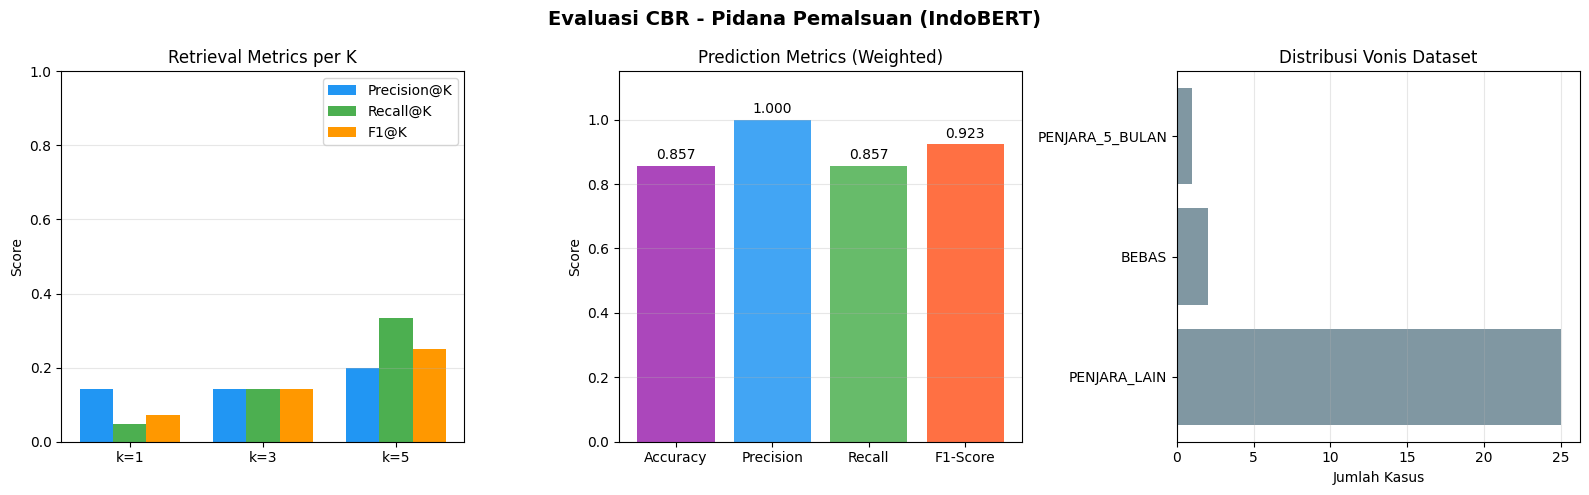

✅ Plot disimpan di: ..\data\eval\evaluation_plot.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Evaluasi CBR - Pidana Pemalsuan (IndoBERT)", fontsize=14, fontweight='bold')

# ---- Plot 1: Retrieval Metrics per K ----
ax1 = axes[0]
k_vals = [1, 3, 5]
p_vals = [retrieval_results.get(f"k={k}", {}).get("precision@k", 0) for k in k_vals]
r_vals = [retrieval_results.get(f"k={k}", {}).get("recall@k", 0) for k in k_vals]
f_vals = [retrieval_results.get(f"k={k}", {}).get("f1@k", 0) for k in k_vals]

x = np.arange(len(k_vals))
w = 0.25
ax1.bar(x - w, p_vals, w, label='Precision@K', color='#2196F3')
ax1.bar(x,     r_vals, w, label='Recall@K',    color='#4CAF50')
ax1.bar(x + w, f_vals, w, label='F1@K',        color='#FF9800')
ax1.set_xticks(x)
ax1.set_xticklabels([f'k={k}' for k in k_vals])
ax1.set_ylim(0, 1.0)
ax1.set_title('Retrieval Metrics per K')
ax1.set_ylabel('Score')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# ---- Plot 2: Prediction Metrics ----
ax2 = axes[1]
met_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
met_values = [
    prediction_metrics["accuracy"],
    prediction_metrics["precision"],
    prediction_metrics["recall"],
    prediction_metrics["f1"]
]
colors = ['#9C27B0', '#2196F3', '#4CAF50', '#FF5722']
bars = ax2.bar(met_names, met_values, color=colors, alpha=0.85)
for bar, val in zip(bars, met_values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax2.set_ylim(0, 1.15)
ax2.set_title('Prediction Metrics (Weighted)')
ax2.set_ylabel('Score')
ax2.grid(axis='y', alpha=0.3)

# ---- Plot 3: Distribusi Vonis Dataset ----
ax3 = axes[2]
vonis_dist = df_all["vonis"].apply(normalize_vonis).value_counts()
vonis_dist = vonis_dist[vonis_dist.index != "TIDAK_DIKETAHUI"]
if len(vonis_dist) > 0:
    ax3.barh(vonis_dist.index[:8], vonis_dist.values[:8], color='#607D8B', alpha=0.8)
    ax3.set_title('Distribusi Vonis Dataset')
    ax3.set_xlabel('Jumlah Kasus')
    ax3.grid(axis='x', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Data vonis\ntidak tersedia', ha='center', va='center',
             transform=ax3.transAxes, fontsize=12)
    ax3.set_title('Distribusi Vonis Dataset')

plt.tight_layout()
plot_path = EVAL_DIR / "evaluation_plot.png"
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Plot disimpan di: {plot_path}")

## 6. Simpan Metrik ke CSV

In [6]:
# Retrieval metrics CSV
retrieval_rows = []
for k_val in [1, 3, 5]:
    m = retrieval_results.get(f"k={k_val}", {})
    retrieval_rows.append({
        "model"      : "IndoBERT",
        "k"          : k_val,
        "precision@k": round(m.get("precision@k", 0), 4),
        "recall@k"   : round(m.get("recall@k", 0), 4),
        "f1@k"       : round(m.get("f1@k", 0), 4),
        "mrr"        : round(m.get("mrr", 0), 4),
        "n_queries"  : m.get("n_queries", 0)
    })

df_ret_metrics = pd.DataFrame(retrieval_rows)
ret_path = EVAL_DIR / "retrieval_metrics.csv"
df_ret_metrics.to_csv(ret_path, index=False, encoding="utf-8-sig")
print(f"✅ Retrieval metrics: {ret_path}")
print(df_ret_metrics.to_string(index=False))

# Prediction metrics CSV
df_pred_metrics = pd.DataFrame([{
    "model"      : "IndoBERT + Weighted Similarity",
    "accuracy"   : round(prediction_metrics["accuracy"], 4),
    "precision"  : round(prediction_metrics["precision"], 4),
    "recall"     : round(prediction_metrics["recall"], 4),
    "f1_score"   : round(prediction_metrics["f1"], 4),
    "n_evaluated": prediction_metrics["n_evaluated"]
}])
pred_met_path = EVAL_DIR / "prediction_metrics.csv"
df_pred_metrics.to_csv(pred_met_path, index=False, encoding="utf-8-sig")
print(f"\n✅ Prediction metrics: {pred_met_path}")
print(df_pred_metrics.to_string(index=False))

✅ Retrieval metrics: ..\data\eval\retrieval_metrics.csv
   model  k  precision@k  recall@k   f1@k    mrr  n_queries
IndoBERT  1       0.1429    0.0476 0.0714 0.1429          7
IndoBERT  3       0.1429    0.1429 0.1429 0.2619          7
IndoBERT  5       0.2000    0.3333 0.2500 0.3262          7

✅ Prediction metrics: ..\data\eval\prediction_metrics.csv
                         model  accuracy  precision  recall  f1_score  n_evaluated
IndoBERT + Weighted Similarity    0.8571        1.0  0.8571    0.9231            7


## 7. Analisis Kegagalan (Error Analysis)

In [7]:
print("\n" + "="*70)
print("📋 ANALISIS KEGAGALAN (ERROR ANALYSIS)")
print("="*70)

if len(df_eval) >= 2:
    # Identifikasi kasus yang diprediksi salah
    df_eval = df_eval.copy()
    df_eval["correct"] = df_eval["actual_norm"] == df_eval["predicted_norm"]
    wrong_cases = df_eval[~df_eval["correct"]]
    
    print(f"\n🔴 Kasus salah prediksi: {len(wrong_cases)} dari {len(df_eval)}")
    
    if len(wrong_cases) > 0:
        print("\nDetail kasus yang salah:")
        for _, row in wrong_cases.iterrows():
            print(f"  - {row['query_id']}: Aktual={row['actual_norm']} | Prediksi={row['predicted_norm']}")
        
        # Pola kesalahan
        print("\nPola kesalahan (Aktual → Prediksi):")
        error_patterns = Counter(zip(wrong_cases["actual_norm"], wrong_cases["predicted_norm"]))
        for (actual, pred), count in error_patterns.most_common():
            print(f"  {actual} → {pred}: {count} kasus")
else:
    print("\n⚠️  Data evaluasi prediksi tidak mencukupi.")
    print("   Kemungkinan penyebab: label vonis belum diekstrak dengan baik dari PDF.")

print("\n" + "="*70)
print("💡 REKOMENDASI PERBAIKAN")
print("="*70)
recommendations = [
    "1. PREPROCESSING: Tingkatkan regex ekstraksi vonis untuk pola yang lebih beragam",
    "   → Tambahkan pola: 'dipidana', 'dijatuhi pidana', 'dihukum penjara'",
    "",
    "2. EMBEDDING: Fine-tuning IndoBERT pada domain hukum Indonesia",
    "   → Gunakan dataset putusan yang lebih besar untuk fine-tuning",
    "   → Pertimbangkan LegalBERT atau model serupa untuk domain hukum",
    "",
    "3. RETRIEVAL: Tambahkan filter pasal sebagai hard constraint",
    "   → Kasus dengan pasal sama diprioritaskan sebelum scoring similarity",
    "   → Hybrid retrieval: BM25 + IndoBERT (dense retrieval)",
    "",
    "4. PREDIKSI: Ensemble majority vote + weighted similarity",
    "   → Gunakan threshold confidence; jika similarity < 0.5 → 'TIDAK YAKIN'",
    "",
    "5. DATA: Tambah jumlah dokumen (target 100+ putusan)",
    "   → Pastikan distribusi pasal merata (263, 264, 266 KUHP, dll.)"
]
for r in recommendations:
    print(r)

print("\n" + "="*70)
print("✅ Tahap 5 selesai! Sistem CBR Pidana Pemalsuan telah dievaluasi.")
print("   Cek file output di /data/eval/ dan /data/results/")
print("="*70)


📋 ANALISIS KEGAGALAN (ERROR ANALYSIS)

🔴 Kasus salah prediksi: 1 dari 7

Detail kasus yang salah:
  - case_027: Aktual=PENJARA_LAIN | Prediksi=BEBAS

Pola kesalahan (Aktual → Prediksi):
  PENJARA_LAIN → BEBAS: 1 kasus

💡 REKOMENDASI PERBAIKAN
1. PREPROCESSING: Tingkatkan regex ekstraksi vonis untuk pola yang lebih beragam
   → Tambahkan pola: 'dipidana', 'dijatuhi pidana', 'dihukum penjara'

2. EMBEDDING: Fine-tuning IndoBERT pada domain hukum Indonesia
   → Gunakan dataset putusan yang lebih besar untuk fine-tuning
   → Pertimbangkan LegalBERT atau model serupa untuk domain hukum

3. RETRIEVAL: Tambahkan filter pasal sebagai hard constraint
   → Kasus dengan pasal sama diprioritaskan sebelum scoring similarity
   → Hybrid retrieval: BM25 + IndoBERT (dense retrieval)

4. PREDIKSI: Ensemble majority vote + weighted similarity
   → Gunakan threshold confidence; jika similarity < 0.5 → 'TIDAK YAKIN'

5. DATA: Tambah jumlah dokumen (target 100+ putusan)
   → Pastikan distribusi pasal mera

## 8. Ringkasan Akhir Sistem CBR

In [8]:
print("\n" + "="*70)
print("📊 RINGKASAN SISTEM CBR - PIDANA UMUM: PEMALSUAN")
print("="*70)
print(f"\n📁 Dataset:")
print(f"   Jenis Perkara    : Pidana Umum - Pemalsuan")
print(f"   Total Dokumen    : {len(df_all)} putusan")
print(f"   Data Train       : {len(df_all) - len(df_test)} kasus")
print(f"   Data Test        : {len(df_test)} kasus")

print(f"\n🤖 Model:")
print(f"   Embedding Model  : IndoBERT (indobenchmark/indobert-base-p1)")
print(f"   Retrieval Method : Cosine Similarity")
print(f"   Prediction Method: Weighted Similarity + Voting")

print(f"\n📈 Performa (k=5):")
m5 = retrieval_results.get("k=5", {})
print(f"   Precision@5 : {m5.get('precision@k', 0):.4f}")
print(f"   Recall@5    : {m5.get('recall@k', 0):.4f}")
print(f"   F1@5        : {m5.get('f1@k', 0):.4f}")
print(f"   MRR         : {m5.get('mrr', 0):.4f}")
print(f"   Pred. F1    : {prediction_metrics['f1']:.4f}")

print(f"\n📂 Output Files:")
print(f"   /data/raw/*.txt                   - {len(df_all)} teks putusan bersih")
print(f"   /data/processed/cases.csv         - Representasi terstruktur")
print(f"   /data/processed/cases.json        - JSON lengkap dengan text_full")
print(f"   /data/eval/train_embeddings.npy   - IndoBERT embeddings")
print(f"   /data/eval/queries.json           - Query uji")
print(f"   /data/eval/retrieval_metrics.csv  - Metrik retrieval")
print(f"   /data/eval/prediction_metrics.csv - Metrik prediksi")
print(f"   /data/results/predictions.csv     - Hasil prediksi")
print("="*70)


📊 RINGKASAN SISTEM CBR - PIDANA UMUM: PEMALSUAN

📁 Dataset:
   Jenis Perkara    : Pidana Umum - Pemalsuan
   Total Dokumen    : 35 putusan
   Data Train       : 28 kasus
   Data Test        : 7 kasus

🤖 Model:
   Embedding Model  : IndoBERT (indobenchmark/indobert-base-p1)
   Retrieval Method : Cosine Similarity
   Prediction Method: Weighted Similarity + Voting

📈 Performa (k=5):
   Precision@5 : 0.2000
   Recall@5    : 0.3333
   F1@5        : 0.2500
   MRR         : 0.3262
   Pred. F1    : 0.9231

📂 Output Files:
   /data/raw/*.txt                   - 35 teks putusan bersih
   /data/processed/cases.csv         - Representasi terstruktur
   /data/processed/cases.json        - JSON lengkap dengan text_full
   /data/eval/train_embeddings.npy   - IndoBERT embeddings
   /data/eval/queries.json           - Query uji
   /data/eval/retrieval_metrics.csv  - Metrik retrieval
   /data/eval/prediction_metrics.csv - Metrik prediksi
   /data/results/predictions.csv     - Hasil prediksi
